In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import os

BASE_PATH = '/content/drive/MyDrive/FinalYearProject/RetinalDieaseFYP'
APTOS_PATH = os.path.join(BASE_PATH, 'aptos2019_sorted')
MESSIDOR_PATH = os.path.join(BASE_PATH, 'messidor/messidor_organized')
KAGGLE_DR_PATH = os.path.join(BASE_PATH, 'kaggle_dr')
RESULTS_PATH = os.path.join(BASE_PATH, 'Transfer_learning_results')


os.makedirs(RESULTS_PATH, exist_ok=True)

# training paramet
IMAGE_SIZE = (224, 224)  # ResNet50 requires 224x224 input
BATCH_SIZE = 32          # Number of images processed together
EPOCHS = 30              # Maximum training iterations
LEARNING_RATE = 0.0001   # Step size for model updates

print("="*80)
print("ResNet50 Transfer Learning - Configuration")
print("="*80)
print(f"\nGPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"Image Size: {IMAGE_SIZE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Maximum Epochs: {EPOCHS}")
print(f"Learning Rate: {LEARNING_RATE}")
print(f"\nResults Directory: {RESULTS_PATH}")

ResNet50 Transfer Learning - Configuration

GPU Available: True
Image Size: (224, 224)
Batch Size: 32
Maximum Epochs: 30
Learning Rate: 0.0001

Results Directory: /content/drive/MyDrive/FinalYearProject/RetinalDieaseFYP/Transfer_learning_results


In [2]:
print("\n" + "="*80)
print("Building ResNet50 Transfer Learning Model")
print("="*80)

# Load pre-trained ResNet50 base model
# model comes with weights from ImageNet training (1.2M images)
# then remove the top classification layer to add another
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(*IMAGE_SIZE, 3)
)

# Freeze the base model weights
# This preserves the learned features from ImageNet
base_model.trainable = False

print(f"\nBase model loaded successfully")
print(f"Total base layers: {len(base_model.layers)}")
print(f"Pre-trained weights: Frozen")

# Add custom classification layers
# Only these layers will be trained on DR dataset
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

# Compile model with binary classification settings
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy',
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall'),
             keras.metrics.AUC(name='auc')]
)

total_params = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
frozen_params = total_params - trainable_params

print(f"\nModel Architecture Summary:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Frozen parameters: {frozen_params:,}")
print(f"  Percentage trainable: {(trainable_params/total_params)*100:.1f}%")

model.summary()


Building ResNet50 Transfer Learning Model
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step

Base model loaded successfully
Total base layers: 175
Pre-trained weights: Frozen

Model Architecture Summary:
  Total parameters: 24,112,513
  Trainable parameters: 524,801
  Frozen parameters: 23,587,712
  Percentage trainable: 2.2%


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [3]:
print("\n" + "="*80)
print("Loading and Preparing Data")
print("="*80)

# Data augmentation for training set and applies random transformations to improve generalization
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    validation_split=0.2
)

# Validation data generator...only rescaling applied, no augmentation
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Load training data from APTOS dataset
print("\nLoading training images...")
train_generator = train_datagen.flow_from_directory(
    APTOS_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True,
    seed=42
)

# Load validation data from APTOS dataset
print("Loading validation images...")
val_generator = val_datagen.flow_from_directory(
    APTOS_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False,
    seed=42
)

print(f"\nData Loading Complete")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")
print(f"Class mapping: {train_generator.class_indices}")

# Displaysss class distribution
train_healthy = np.sum(train_generator.classes == 0)
train_unhealthy = np.sum(train_generator.classes == 1)

print(f"\nTraining Set Distribution:")
print(f"  Healthy: {train_healthy} ({train_healthy/train_generator.samples*100:.1f}%)")
print(f"  Unhealthy: {train_unhealthy} ({train_unhealthy/train_generator.samples*100:.1f}%)")


Loading and Preparing Data

Loading training images...
Found 1835 images belonging to 2 classes.
Loading validation images...
Found 458 images belonging to 2 classes.

Data Loading Complete
Training samples: 1835
Validation samples: 458
Class mapping: {'healthy': 0, 'unhealthy': 1}

Training Set Distribution:
  Healthy: 926 (50.5%)
  Unhealthy: 909 (49.5%)


In [4]:
print("\n" + "="*80)
print("Training ResNet50 Model")
print("="*80)

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        os.path.join(RESULTS_PATH, 'resnet50_best.h5'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

start_time = datetime.now()
print(f"\nTraining started: {start_time.strftime('%H:%M:%S')}")
print(f"Expected duration: 20-30 minutes with GPU acceleration\n")

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

end_time = datetime.now()
training_time = end_time - start_time

print("\n" + "="*80)
print("Training Completed")
print("="*80)
print(f"Total training time: {training_time}")
print(f"Epochs completed: {len(history.history['loss'])}")


Training ResNet50 Model

Training started: 23:43:02
Expected duration: 20-30 minutes with GPU acceleration



/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.4765 - auc: 0.4825 - loss: 0.8306 - precision: 0.4721 - recall: 0.4471 
Epoch 1: val_accuracy improved from -inf to 0.51092, saving model to /content/drive/MyDrive/FinalYearProject/RetinalDieaseFYP/Transfer_learning_results/resnet50_best.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 1088s 19s/step - accuracy: 0.4767 - auc: 0.4826 - loss: 0.8301 - precision: 0.4724 - recall: 0.4477 - val_accuracy: 0.5109 - val_auc: 0.7471 - val_loss: 0.6893 - val_precision: 1.0000 - val_recall: 0.0132 - learning_rate: 1.0000e-04
Epoch 2/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4893 - auc: 0.4939 - loss: 0.7708 - precision: 0.4830 - recall: 0.4769
Epoch 2: val_accuracy did not improve from 0.51092
58/58 ━━━━━━━━━━━━━━━━━━━━ 290s 5s/step - accuracy: 0.4892 - auc: 0.4940 - loss: 0.7705 - precision: 0.4830 - recall: 0.4771 - val_accuracy: 0.5044 - val_auc: 0.8611 - val_loss: 0.6899 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 3/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5077 - auc: 0.5128 - loss: 0.7398 - precision: 0.5071 - recall: 0.4593
Epoch 3: val_accuracy improved from 0.51092 to 0.60044, saving model to /content/drive/MyDrive/FinalYearProject/RetinalDieaseFYP/Transfer_learning_results/

58/58 ━━━━━━━━━━━━━━━━━━━━ 322s 5s/step - accuracy: 0.5078 - auc: 0.5129 - loss: 0.7397 - precision: 0.5072 - recall: 0.4595 - val_accuracy: 0.6004 - val_auc: 0.8765 - val_loss: 0.6842 - val_precision: 0.5537 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5174 - auc: 0.5137 - loss: 0.7207 - precision: 0.5149 - recall: 0.5613
Epoch 4: val_accuracy did not improve from 0.60044
58/58 ━━━━━━━━━━━━━━━━━━━━ 287s 5s/step - accuracy: 0.5171 - auc: 0.5135 - loss: 0.7207 - precision: 0.5146 - recall: 0.5605 - val_accuracy: 0.5044 - val_auc: 0.8906 - val_loss: 0.6836 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 5/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5031 - auc: 0.5059 - loss: 0.7182 - precision: 0.5169 - recall: 0.4643
Epoch 5: val_accuracy did not improve from 0.60044
58/58 ━━━━━━━━━━━━━━━━━━━━ 281s 5s/step - accuracy: 0.5032 - auc: 0.5060 - loss: 0.7181 - precision: 0.516

...

58/58 ━━━━━━━━━━━━━━━━━━━━ 283s 5s/step - accuracy: 0.5369 - auc: 0.5406 - loss: 0.6948 - precision: 0.5423 - recall: 0.6201 - val_accuracy: 0.7162 - val_auc: 0.9068 - val_loss: 0.6747 - val_precision: 0.9533 - val_recall: 0.4493 - learning_rate: 1.0000e-04
Epoch 8/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5382 - auc: 0.5516 - loss: 0.6890 - precision: 0.5269 - recall: 0.4427
Epoch 8: val_accuracy improved from 0.71616 to 0.80568, saving model to /content/drive/MyDrive/FinalYearProject/RetinalDieaseFYP/Transfer_learning_results/resnet50_best.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 281s 5s/step - accuracy: 0.5381 - auc: 0.5514 - loss: 0.6891 - precision: 0.5269 - recall: 0.4437 - val_accuracy: 0.8057 - val_auc: 0.9052 - val_loss: 0.6733 - val_precision: 0.7363 - val_recall: 0.9471 - learning_rate: 1.0000e-04
Epoch 9/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5406 - auc: 0.5622 - loss: 0.6875 - precision: 0.5385 - recall: 0.4959
Epoch 9: val_accuracy did not improve from 0.80568
58/58 ━━━━━━━━━━━━━━━━━━━━ 278s 5s/step - accuracy: 0.5408 - auc: 0.5624 - loss: 0.6874 - precision: 0.5387 - recall: 0.4962 - val_accuracy: 0.6856 - val_auc: 0.8965 - val_loss: 0.6714 - val_precision: 0.9770 - val_recall: 0.3744 - learning_rate: 1.0000e-04
Epoch 10/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5282 - auc: 0.5415 - loss: 0.6915 - precision: 0.5203 - recall: 0.4245
Epoch 10: val_accuracy did not improve from 0.80568
58/58 ━━━━━━━━━━━━━━━━━━━━ 278s 5s/step - accuracy: 0.5283 - auc: 0.5416 - loss: 0.6915 - precision: 0.5205 - re

58/58 ━━━━━━━━━━━━━━━━━━━━ 280s 5s/step - accuracy: 0.5639 - auc: 0.5846 - loss: 0.6832 - precision: 0.5620 - recall: 0.5899 - val_accuracy: 0.8231 - val_auc: 0.9031 - val_loss: 0.6671 - val_precision: 0.8288 - val_recall: 0.8106 - learning_rate: 1.0000e-04
Epoch 12/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5841 - auc: 0.6106 - loss: 0.6782 - precision: 0.5859 - recall: 0.5943
Epoch 12: val_accuracy did not improve from 0.82314
58/58 ━━━━━━━━━━━━━━━━━━━━ 279s 5s/step - accuracy: 0.5838 - auc: 0.6102 - loss: 0.6783 - precision: 0.5855 - recall: 0.5942 - val_accuracy: 0.5044 - val_auc: 0.9110 - val_loss: 0.6731 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 13/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5468 - auc: 0.5707 - loss: 0.6861 - precision: 0.5868 - recall: 0.4515
Epoch 13: val_accuracy did not improve from 0.82314
58/58 ━━━━━━━━━━━━━━━━━━━━ 279s 5s/step - accuracy: 0.5467 - auc: 0.5705 - loss: 0.6861 - precision: 0

58/58 ━━━━━━━━━━━━━━━━━━━━ 282s 5s/step - accuracy: 0.5836 - auc: 0.6134 - loss: 0.6771 - precision: 0.5964 - recall: 0.5374 - val_accuracy: 0.8297 - val_auc: 0.9126 - val_loss: 0.6531 - val_precision: 0.8253 - val_recall: 0.8326 - learning_rate: 1.0000e-04
Epoch 22/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5789 - auc: 0.6138 - loss: 0.6767 - precision: 0.5894 - recall: 0.6145
Epoch 22: val_accuracy did not improve from 0.82969
58/58 ━━━━━━━━━━━━━━━━━━━━ 280s 5s/step - accuracy: 0.5791 - auc: 0.6140 - loss: 0.6767 - precision: 0.5895 - recall: 0.6134 - val_accuracy: 0.6070 - val_auc: 0.9095 - val_loss: 0.6568 - val_precision: 0.5577 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 23/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6009 - auc: 0.6609 - loss: 0.6724 - precision: 0.5858 - recall: 0.7148
Epoch 23: val_accuracy did not improve from 0.82969
58/58 ━━━━━━━━━━━━━━━━━━━━ 280s 5s/step - accuracy: 0.6010 - auc: 0.6608 - loss: 0.6724 - precision: 0.5862 - 

58/58 ━━━━━━━━━━━━━━━━━━━━ 280s 5s/step - accuracy: 0.6041 - auc: 0.6598 - loss: 0.6698 - precision: 0.6181 - recall: 0.4706 - val_accuracy: 0.8319 - val_auc: 0.9117 - val_loss: 0.6454 - val_precision: 0.7953 - val_recall: 0.8899 - learning_rate: 1.0000e-04
Epoch 26/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6134 - auc: 0.6642 - loss: 0.6693 - precision: 0.6343 - recall: 0.5069
Epoch 26: val_accuracy did not improve from 0.83188
58/58 ━━━━━━━━━━━━━━━━━━━━ 277s 5s/step - accuracy: 0.6130 - auc: 0.6637 - loss: 0.6693 - precision: 0.6336 - recall: 0.5073 - val_accuracy: 0.7227 - val_auc: 0.9117 - val_loss: 0.6441 - val_precision: 0.9386 - val_recall: 0.4714 - learning_rate: 1.0000e-04
Epoch 27/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6114 - auc: 0.6848 - loss: 0.6653 - precision: 0.6536 - recall: 0.4578
Epoch 27: val_accuracy did not improve from 0.83188
58/58 ━━━━━━━━━━━━━━━━━━━━ 279s 5s/step - accuracy: 0.6115 - auc: 0.6846 - loss: 0.6653 - precision: 0.6531 - 

In [5]:
print("ResNet50 Model Evaluation")

# Load best model weights
model.load_weights(os.path.join(RESULTS_PATH, 'resnet50_best.h5'))
print("Best model weights loaded (Epoch 25)\n")

# Evaluate on APTOS validation set
print("Testing on APTOS Validation Set")

val_results = model.evaluate(val_generator, verbose=0)
val_loss, val_acc, val_precision, val_recall, val_auc = val_results
val_f1 = 2 * (val_precision * val_recall) / (val_precision + val_recall + 1e-7)

print(f"\nAPTOS Validation Results:")
print(f"  Accuracy:  {val_acc*100:.2f}%")
print(f"  Precision: {val_precision*100:.2f}%")
print(f"  Recall:    {val_recall*100:.2f}%")
print(f"  F1-Score:  {val_f1*100:.2f}%")
print(f"  AUC:       {val_auc:.4f}")

print("Testing on Messidor Dataset (Cross-Dataset Validation)")

messidor_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    MESSIDOR_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print(f"Messidor samples: {messidor_gen.samples}\n")

messidor_results = model.evaluate(messidor_gen, verbose=0)
messidor_loss, messidor_acc, messidor_precision, messidor_recall, messidor_auc = messidor_results
messidor_f1 = 2 * (messidor_precision * messidor_recall) / (messidor_precision + messidor_recall + 1e-7)

print(f"Messidor Results:")
print(f"  Accuracy:  {messidor_acc*100:.2f}%")
print(f"  Precision: {messidor_precision*100:.2f}%")
print(f"  Recall:    {messidor_recall*100:.2f}%")
print(f"  F1-Score:  {messidor_f1*100:.2f}%")
print(f"  AUC:       {messidor_auc:.4f}")

print("Testing on Kaggle DR Dataset (Cross-Dataset Validation)")

kaggle_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    KAGGLE_DR_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print(f"Kaggle DR samples: {kaggle_gen.samples}\n")

kaggle_results = model.evaluate(kaggle_gen, verbose=0)
kaggle_loss, kaggle_acc, kaggle_precision, kaggle_recall, kaggle_auc = kaggle_results
kaggle_f1 = 2 * (kaggle_precision * kaggle_recall) / (kaggle_precision + kaggle_recall + 1e-7)

print(f"Kaggle DR Results:")
print(f"  Accuracy:  {kaggle_acc*100:.2f}%")
print(f"  Precision: {kaggle_precision*100:.2f}%")
print(f"  Recall:    {kaggle_recall*100:.2f}%")
print(f"  F1-Score:  {kaggle_f1*100:.2f}%")
print(f"  AUC:       {kaggle_auc:.4f}")

# Calculate generalization gaps
gen_gap_messidor = val_acc - messidor_acc
gen_gap_kaggle = val_acc - kaggle_acc

print("Saving Results")

results_df = pd.DataFrame({
    'Model': ['ResNet50'],
    'Total_Parameters': [total_params],
    'Trainable_Parameters': [trainable_params],
    'Training_Time_Minutes': [training_time.total_seconds() / 60],
    'Epochs_Completed': [len(history.history['loss'])],
    'APTOS_Accuracy': [val_acc],
    'APTOS_Precision': [val_precision],
    'APTOS_Recall': [val_recall],
    'APTOS_F1': [val_f1],
    'APTOS_AUC': [val_auc],
    'Messidor_Accuracy': [messidor_acc],
    'Messidor_Precision': [messidor_precision],
    'Messidor_Recall': [messidor_recall],
    'Messidor_F1': [messidor_f1],
    'Messidor_AUC': [messidor_auc],
    'Kaggle_DR_Accuracy': [kaggle_acc],
    'Kaggle_DR_Precision': [kaggle_precision],
    'Kaggle_DR_Recall': [kaggle_recall],
    'Kaggle_DR_F1': [kaggle_f1],
    'Kaggle_DR_AUC': [kaggle_auc],
    'Generalization_Gap_Messidor': [gen_gap_messidor],
    'Generalization_Gap_Kaggle': [gen_gap_kaggle]
})

results_df.to_csv(os.path.join(RESULTS_PATH, 'resnet50_results.csv'), index=False)
model.save(os.path.join(RESULTS_PATH, 'resnet50_final.h5'))

print("\nResults saved:")
print(" resnet50_results.csv")
print(" resnet50_best.h5")
print(" resnet50_final.h5")

# Display final comparison
print("ResNet50 Performance Summary")

print(f"\n{'Dataset':<20} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("-" * 68)
print(f"{'APTOS Validation':<20} {val_acc*100:>6.2f}%     {val_precision*100:>6.2f}%     {val_recall*100:>6.2f}%     {val_f1*100:>6.2f}%")
print(f"{'Messidor Test':<20} {messidor_acc*100:>6.2f}%     {messidor_precision*100:>6.2f}%     {messidor_recall*100:>6.2f}%     {messidor_f1*100:>6.2f}%")
print(f"{'Kaggle DR Test':<20} {kaggle_acc*100:>6.2f}%     {kaggle_precision*100:>6.2f}%     {kaggle_recall*100:>6.2f}%     {kaggle_f1*100:>6.2f}%")

print(f"\nGeneralization Analysis:")
print(f"  APTOS to Messidor gap:   {gen_gap_messidor*100:>6.2f}%")
print(f"  APTOS to Kaggle DR gap:  {gen_gap_kaggle*100:>6.2f}%")

print(f"\nTraining Summary:")
print(f"  Total training time: {training_time}")
print(f"  Epochs completed: 30")
print(f"  Best epoch: 25")

print("ResNet50 Evaluation Complete")

ResNet50 Model Evaluation
Best model weights loaded (Epoch 25)

Testing on APTOS Validation Set

APTOS Validation Results:
  Accuracy:  83.19%
  Precision: 79.53%
  Recall:    88.99%
  F1-Score:  83.99%
  AUC:       0.9117
Testing on Messidor Dataset (Cross-Dataset Validation)
Found 1200 images belonging to 2 classes.
Messidor samples: 1200

Messidor Results:
  Accuracy:  45.42%
  Precision: 0.00%
  Recall:    0.00%
  F1-Score:  0.00%
  AUC:       0.4788
Testing on Kaggle DR Dataset (Cross-Dataset Validation)
Found 3662 images belonging to 2 classes.
Kaggle DR samples: 3662



Kaggle DR Results:
  Accuracy:  85.42%
  Precision: 82.41%
  Recall:    90.58%
  F1-Score:  86.30%
  AUC:       0.9146
Saving Results

Results saved:
 resnet50_results.csv
 resnet50_best.h5
 resnet50_final.h5
ResNet50 Performance Summary

Dataset              Accuracy     Precision    Recall       F1          
--------------------------------------------------------------------
APTOS Validation      83.19%      79.53%      88.99%      83.99%
Messidor Test         45.42%       0.00%       0.00%       0.00%
Kaggle DR Test        85.42%      82.41%      90.58%      86.30%

Generalization Analysis:
  APTOS to Messidor gap:    37.77%
  APTOS to Kaggle DR gap:   -2.23%

Training Summary:
  Total training time: 2:40:00.343953
  Epochs completed: 30
  Best epoch: 25
ResNet50 Evaluation Complete


Creating ResNet50 Visualizations

Saved: resnet50_performance_comparison.png


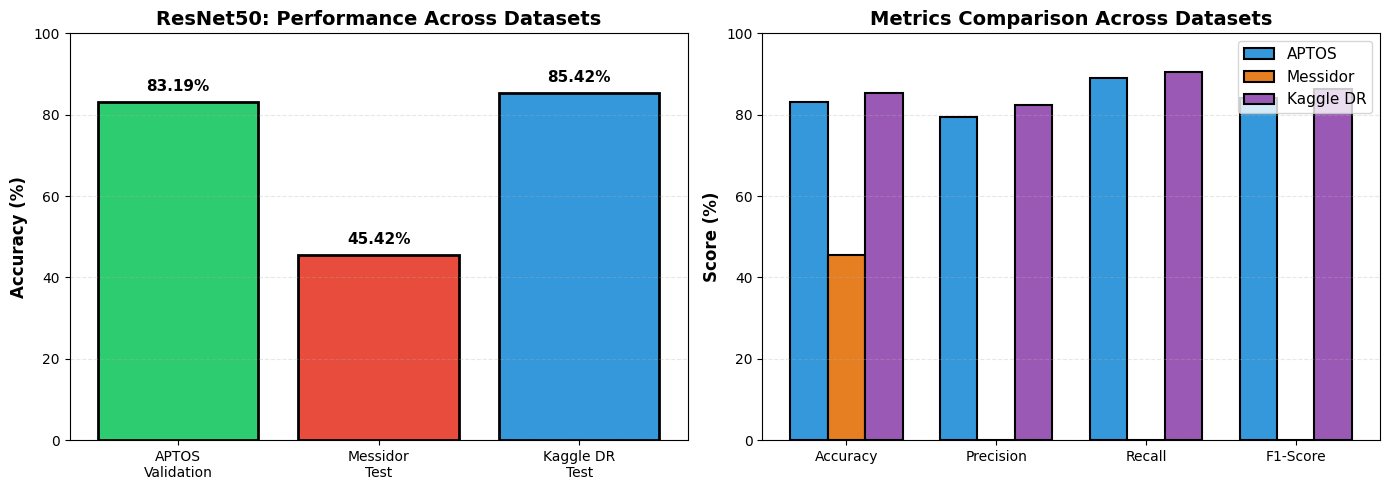

Saved: resnet50_summary_table.png


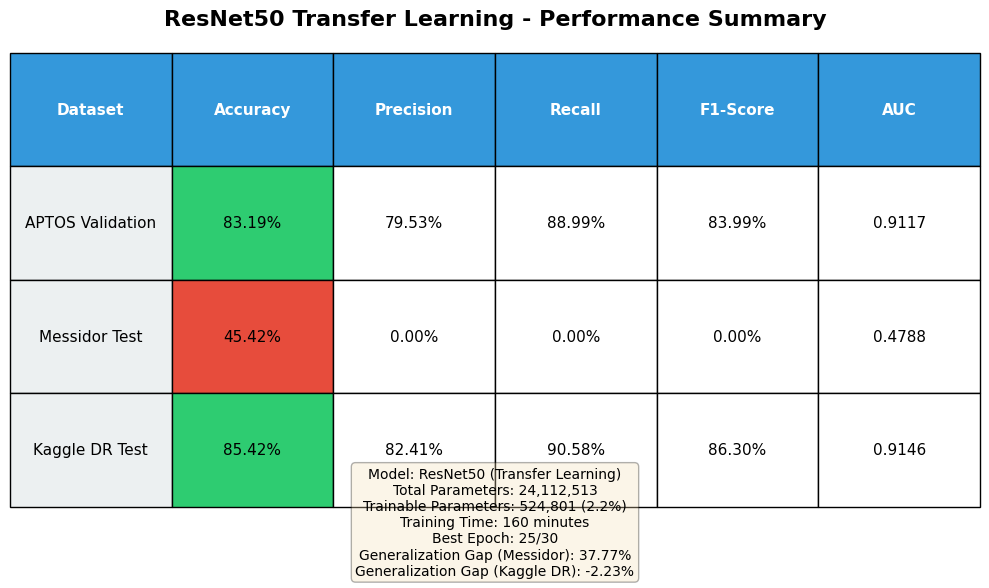

Saved: resnet50_cnn_comparison.png


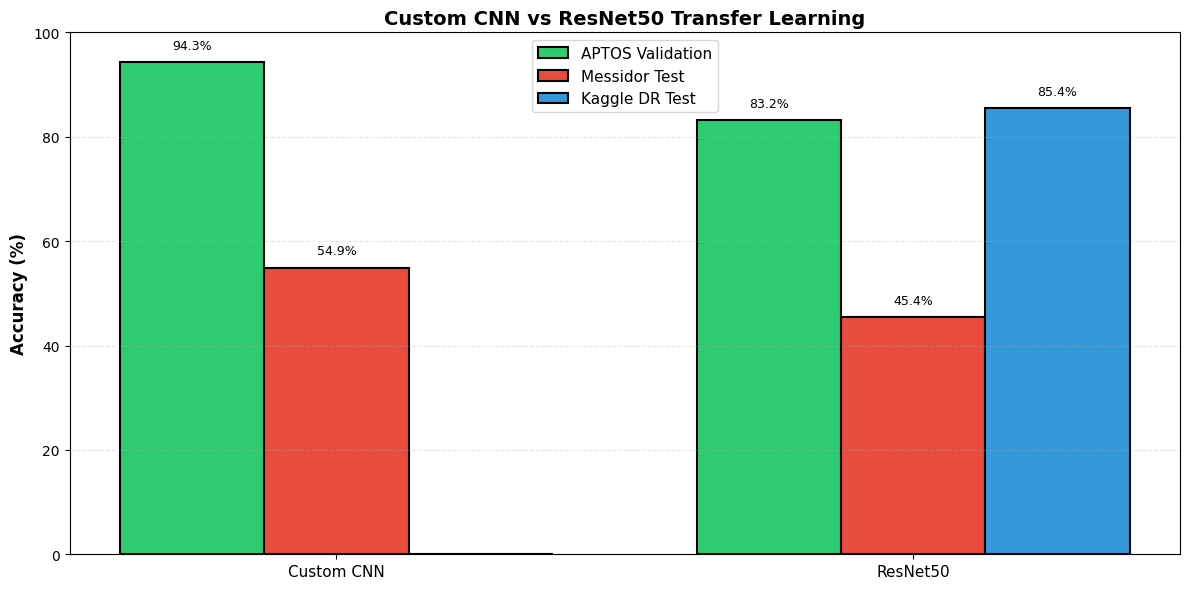

All ResNet50 visualizations created successfully


In [7]:
import matplotlib.pyplot as plt
import numpy as np

print("Creating ResNet50 Visualizations")

# Use the results i already have
# APTOS: 83.19%, Messidor: 45.42%, Kaggle DR: 85.42%

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dataset accuracy comparison
datasets = ['APTOS\nValidation', 'Messidor\nTest', 'Kaggle DR\nTest']
accuracies = [83.19, 45.42, 85.42]
colors = ['#2ecc71', '#e74c3c', '#3498db']

bars = axes[0].bar(datasets, accuracies, color=colors, edgecolor='black', linewidth=2)
axes[0].set_ylim([0, 100])
axes[0].set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
axes[0].set_title('ResNet50: Performance Across Datasets', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{height:.2f}%',
                ha='center', va='bottom', fontweight='bold', fontsize=11)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
aptos_metrics = [83.19, 79.53, 88.99, 83.99]
messidor_metrics = [45.42, 0.00, 0.00, 0.00]
kaggle_metrics = [85.42, 82.41, 90.58, 86.30]

x = np.arange(len(metrics))
width = 0.25

bars1 = axes[1].bar(x - width, aptos_metrics, width, label='APTOS',
                   color='#3498db', edgecolor='black', linewidth=1.5)
bars2 = axes[1].bar(x, messidor_metrics, width, label='Messidor',
                   color='#e67e22', edgecolor='black', linewidth=1.5)
bars3 = axes[1].bar(x + width, kaggle_metrics, width, label='Kaggle DR',
                   color='#9b59b6', edgecolor='black', linewidth=1.5)

axes[1].set_ylabel('Score (%)', fontsize=12, fontweight='bold')
axes[1].set_title('Metrics Comparison Across Datasets', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics, fontsize=10)
axes[1].legend(fontsize=11)
axes[1].set_ylim([0, 100])
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plot1_path = os.path.join(RESULTS_PATH, 'resnet50_performance_comparison.png')
plt.savefig(plot1_path, dpi=300, bbox_inches='tight')
print(f"\nSaved: resnet50_performance_comparison.png")
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))

summary_data = [
    ['APTOS Validation', '83.19%', '79.53%', '88.99%', '83.99%', '0.9117'],
    ['Messidor Test', '45.42%', '0.00%', '0.00%', '0.00%', '0.4788'],
    ['Kaggle DR Test', '85.42%', '82.41%', '90.58%', '86.30%', '0.9146']
]

table = ax.table(cellText=summary_data,
                colLabels=['Dataset', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC'],
                cellLoc='center',
                loc='center',
                bbox=[0, 0, 1, 1])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

for i in range(6):
    table[(0, i)].set_facecolor('#3498db')
    table[(0, i)].set_text_props(weight='bold', color='white')

table[(1, 0)].set_facecolor('#ecf0f1')
table[(2, 0)].set_facecolor('#ecf0f1')
table[(3, 0)].set_facecolor('#ecf0f1')

table[(1, 1)].set_facecolor('#2ecc71')
table[(2, 1)].set_facecolor('#e74c3c')
table[(3, 1)].set_facecolor('#2ecc71')

ax.axis('off')
ax.set_title('ResNet50 Transfer Learning - Performance Summary', fontsize=16, fontweight='bold', pad=20)

info_text = 'Model: ResNet50 (Transfer Learning)\n'
info_text += 'Total Parameters: 24,112,513\n'
info_text += 'Trainable Parameters: 524,801 (2.2%)\n'
info_text += 'Training Time: 160 minutes\n'
info_text += 'Best Epoch: 25/30\n'
info_text += 'Generalization Gap (Messidor): 37.77%\n'
info_text += 'Generalization Gap (Kaggle DR): -2.23%'

ax.text(0.5, -0.15, info_text, transform=ax.transAxes,
        fontsize=10, ha='center',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plot2_path = os.path.join(RESULTS_PATH, 'resnet50_summary_table.png')
plt.savefig(plot2_path, dpi=300, bbox_inches='tight')
print(f"Saved: resnet50_summary_table.png")
plt.show()

# Comparison with Custom CNN
fig, ax = plt.subplots(figsize=(12, 6))

models_list = ['Custom CNN', 'ResNet50']
aptos_scores = [94.32, 83.19]
messidor_scores = [54.92, 45.42]
kaggle_scores = [0, 85.42]  # Custom CNN wasn't tested on Kaggle DR

x = np.arange(len(models_list))
width = 0.25

bars1 = ax.bar(x - width, aptos_scores, width, label='APTOS Validation',
               color='#2ecc71', edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x, messidor_scores, width, label='Messidor Test',
               color='#e74c3c', edgecolor='black', linewidth=1.5)
bars3 = ax.bar(x + width, kaggle_scores, width, label='Kaggle DR Test',
               color='#3498db', edgecolor='black', linewidth=1.5)

ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Custom CNN vs ResNet50 Transfer Learning', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models_list, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim([0, 100])
ax.grid(axis='y', alpha=0.3, linestyle='--')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height + 2,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plot3_path = os.path.join(RESULTS_PATH, 'resnet50_cnn_comparison.png')
plt.savefig(plot3_path, dpi=300, bbox_inches='tight')
print(f"Saved: resnet50_cnn_comparison.png")
plt.show()

print("All ResNet50 visualizations created successfully")
